In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings("ignore")

from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,roc_auc_score,roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC 

from imblearn.over_sampling import RandomOverSampler,SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.combine import SMOTEENN

In [2]:
plt.rcParams["figure.figsize"]=[10,6]

In [3]:
data = pd.read_csv(r"C:\Users\admin\Downloads\archive (6)\loan_data.csv")
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
data.shape

(45000, 14)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

Text(0, 0.5, 'Over All size of Data ')

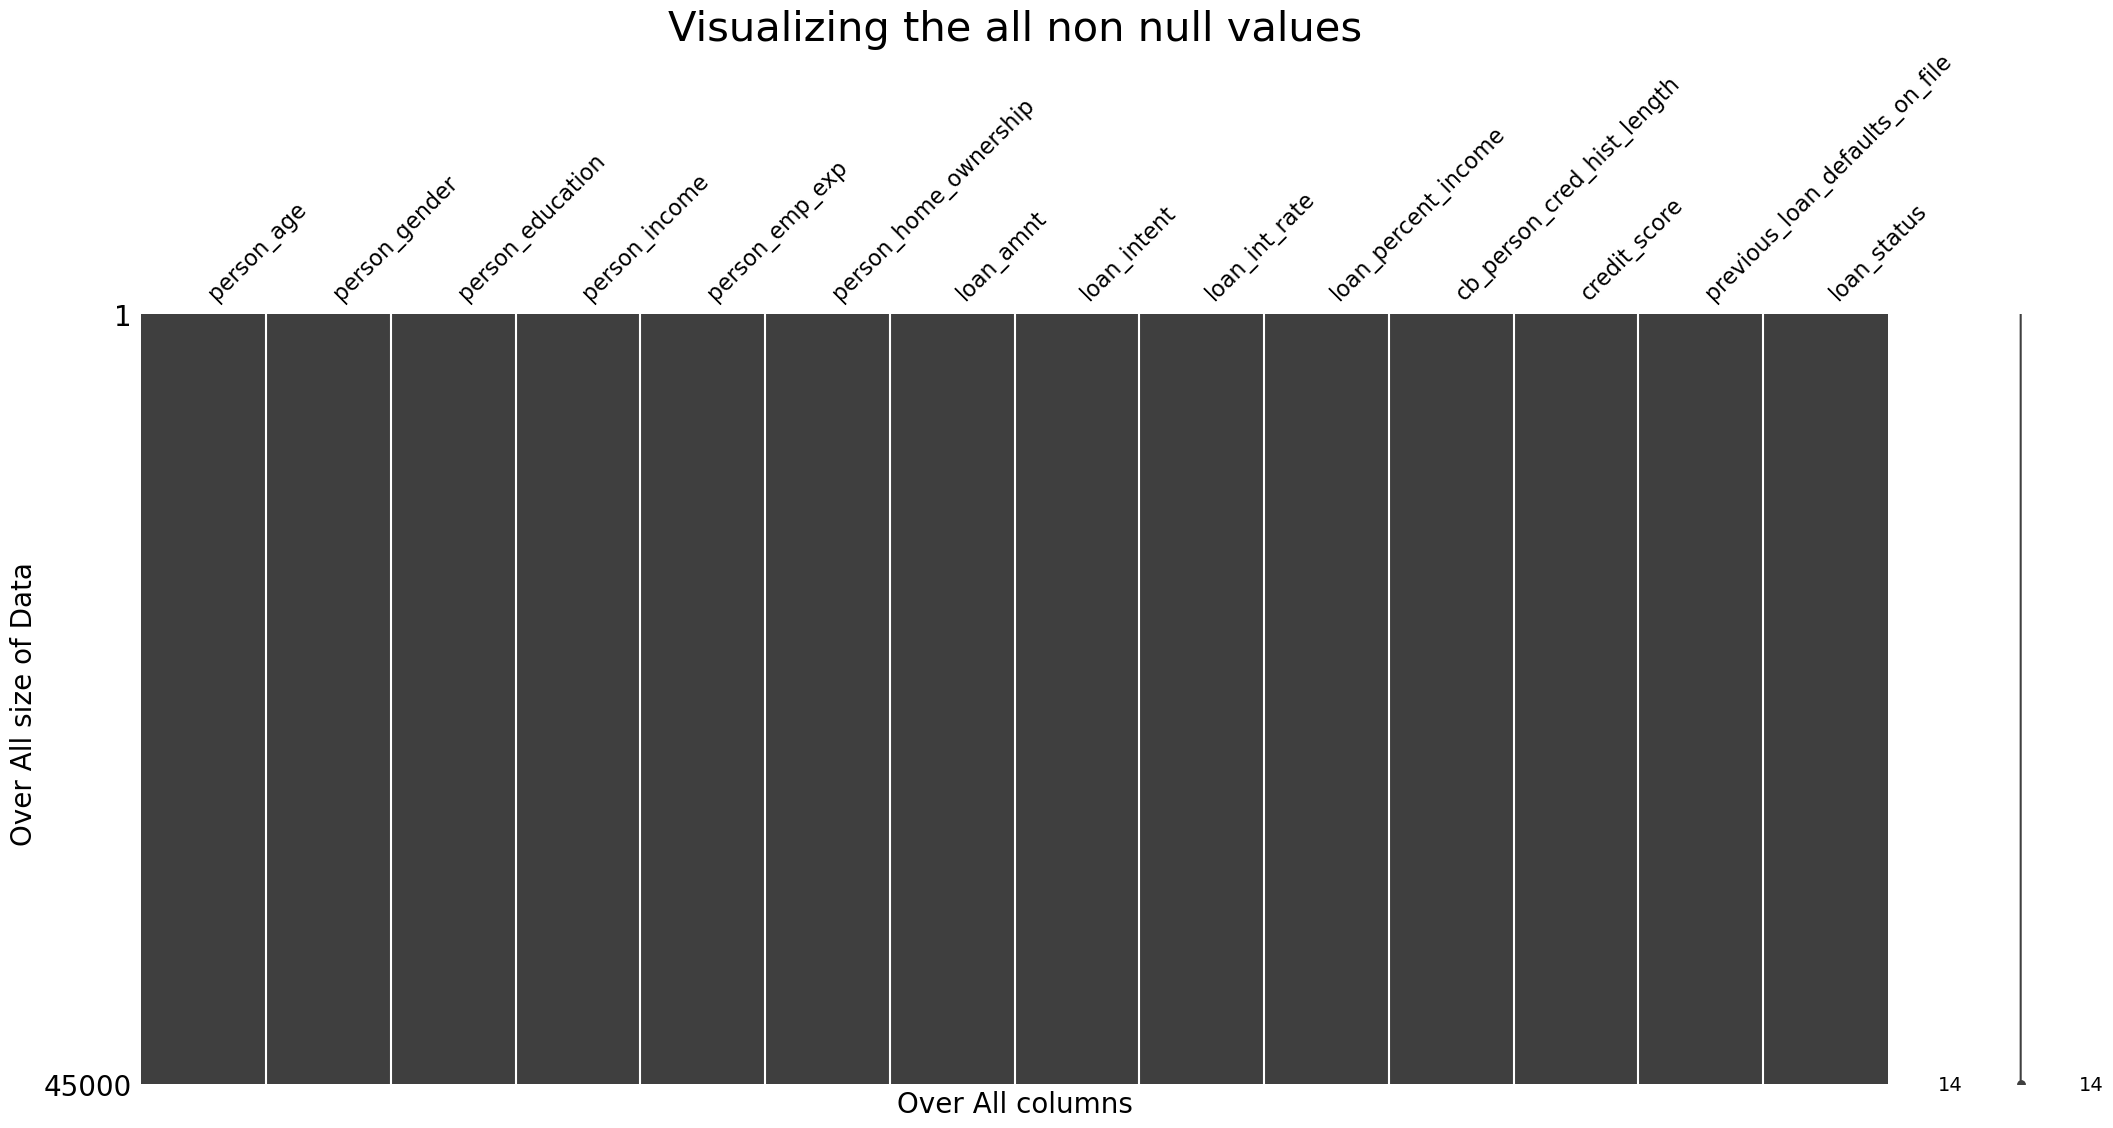

In [6]:
import missingno as mn
mn.matrix(data)
plt.title("Visualizing the all non null values",fontdict={"fontsize":30})
plt.xlabel("Over All columns",fontdict={"fontsize":20})
plt.ylabel("Over All size of Data ",fontdict={"fontsize":20})

In [7]:
data.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [8]:
num = data.select_dtypes(include="number")
cat = data.select_dtypes(include="object")

In [9]:
num.columns,len(num.columns)

(Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
        'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
        'credit_score', 'loan_status'],
       dtype='object'),
 9)

In [10]:
cat.columns,len(cat.columns)

(Index(['person_gender', 'person_education', 'person_home_ownership',
        'loan_intent', 'previous_loan_defaults_on_file'],
       dtype='object'),
 5)

In [11]:
data.head(1)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1


In [12]:
label = LabelEncoder()
data["person_gender"] = label.fit_transform(data["person_gender"])
data["person_education"] = label.fit_transform(data["person_education"])
data["person_home_ownership"] = label.fit_transform(data["person_home_ownership"])
data["loan_intent"] = label.fit_transform(data["loan_intent"])
data["previous_loan_defaults_on_file"] = label.fit_transform(data["previous_loan_defaults_on_file"])

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  int32  
 2   person_education                45000 non-null  int32  
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  int32  
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  int32  
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [14]:
# i=1
# plt.figure(figsize=[15,20])
# for col in data.columns:
#     plt.subplot(8,2,i)
#     df=data.copy()
#     df.boxplot(column=col)
#     plt.xlabel(col)
#     plt.ylabel(col)
#     plt.tight_layout()
#     i+=1

In [15]:
# q1 = data.select_dtypes(include="number").quantile(0.25)
# q3 = data.select_dtypes(include="number").quantile(0.75)
# iqr = q3 - q1
# iqr

In [16]:
# data = data[~(
#         ((data[q1.index] < (q1 - 1.5 *iqr)) |
#         (data[q1.index]  > (q3 + 1.5 *iqr))).any(axis=1)
# )]

In [17]:
# i=1
# plt.figure(figsize=[15,20])
# for col in data.columns:
#     plt.subplot(8,2,i)
#     df=data.copy()
#     df.boxplot(column=col)
#     plt.xlabel(col)
#     plt.ylabel(col)
#     plt.tight_layout()
#     i+=1

In [18]:
data.shape

(45000, 14)

In [19]:
data = data.reset_index(drop=True)

In [20]:
x = data.drop(["loan_status"],axis=1)
y = data.loan_status

In [21]:
# data["loan_status"].value_counts()
ny = y.value_counts().reset_index()
ny.columns = ["value","counts"]
ny

,value,counts
0,0,35000
1,1,10000


Text(0.95, 10001, '22.2222%')

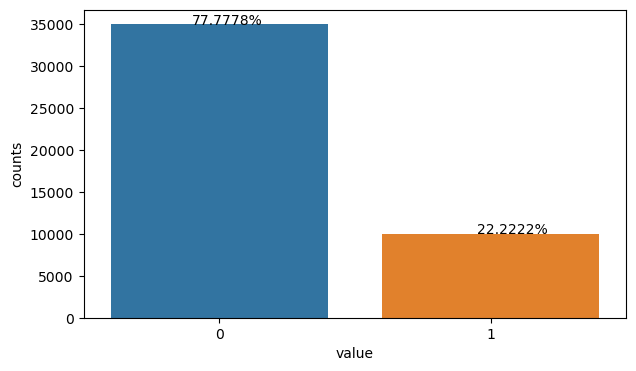

In [22]:
plt.figure(figsize=[7,4])
sns.barplot(data=ny,x="value",y="counts")
plt.text(x=-0.1,y=y.value_counts()[0]+1,s=str(round(y.value_counts()[0]*100/len(y),4))+"%")
plt.text(x=0.95,y=y.value_counts()[1]+1,s=str(round(y.value_counts()[1]*100/len(y),4))+"%")

### sampling.. we are sampling data into equal quantity

In [23]:
smt = SMOTETomek(random_state=42)
x1,y1 = smt.fit_resample(x,y)

In [24]:
yy = y1.value_counts().reset_index()
yy.columns = ["value","counts"]
yy

,value,counts
0,1,32806
1,0,32806


Text(0.95, 32807, '50.0%')

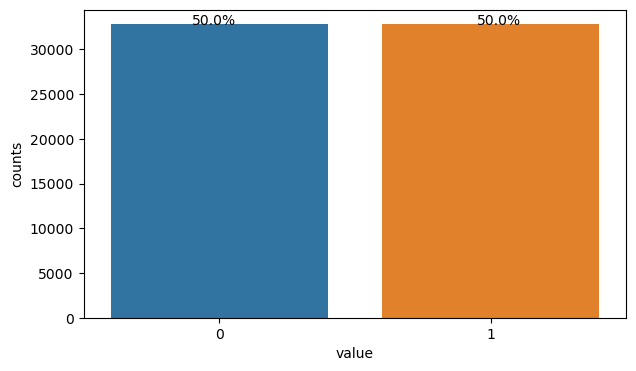

In [25]:
plt.figure(figsize=[7,4])
sns.barplot(data=yy,x="value",y="counts")
plt.text(x=-0.1,y=y1.value_counts()[0]+1,s=str(round(y1.value_counts()[0]*100/len(y1),4))+"%")
plt.text(x=0.95,y=y1.value_counts()[1]+1,s=str(round(y1.value_counts()[1]*100/len(y1),4))+"%")

In [26]:
sme = SMOTEENN(random_state=42)
x2,y2 = sme.fit_resample(x,y)

In [27]:
y2.shape 

(47599,)

In [28]:
yy1 = y2.value_counts().reset_index()
yy1.columns = ["value","counts"]
yy1

,value,counts
0,1,24831
1,0,22768


Text(0.95, 24832, '52.1671%')

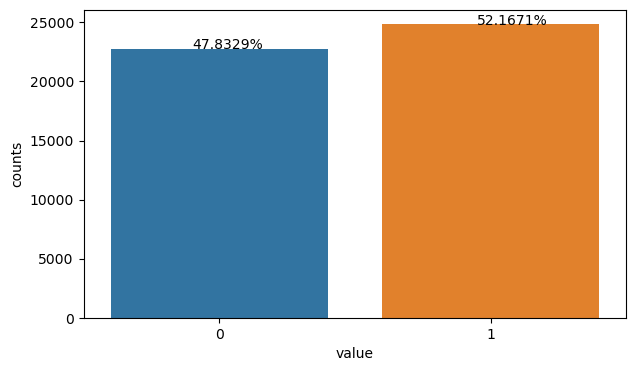

In [29]:
plt.figure(figsize=[7,4])
sns.barplot(data=yy1,x="value",y="counts")
plt.text(x=-0.1,y=y2.value_counts()[0]+1,s=str(round(y2.value_counts()[0]*100/len(y2),4))+"%")
plt.text(x=0.95,y=y2.value_counts()[1]+1,s=str(round(y2.value_counts()[1]*100/len(y2),4))+"%")

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x2,y2,test_size=0.2,random_state=42)

In [31]:
def train_acc(model):
    model.fit(x_train,y_train)
    y_pre = model.predict(x_test)
    acc=accuracy_score(y_test,y_pre)
    return acc

In [32]:
def test_acc(model):
    model.fit(x_test,y_test)
    y_pre = model.predict(x_train)
    acc=accuracy_score(y_train,y_pre)
    return acc

In [33]:
def train_class_report(model):
    model.fit(x_train,y_train)
    y_pre = model.predict(x_test)
    class_report = classification_report(y_test,y_pre)
    return (class_report)

In [34]:
def test_class_report(model):
    model.fit(x_test,y_test)
    y_pre = model.predict(x_train)
    class_report = classification_report(y_train,y_pre)
    return (class_report)

In [35]:
def conf_matrix(model):
    model.fit(x_train,y_train)
    y_pre = model.predict(x_test)
    cm=confusion_matrix(y_test,y_pre)
    plt.figure(figsize=(5,3))
    con_table = pd.DataFrame(data=cm,columns=["Predicted:0","predicted:1"],index = ["actual:0","actual:1"])
    sns.heatmap(con_table,annot=True,cmap="coolwarm",cbar=True,annot_kws={"size":15})
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()

In [79]:
table = pd.DataFrame(columns=["Model","feature","Train/Test","Accuracy"])

def update_table(model,train_test,accuracy,feature='-'):
    global table;
    table.loc[len(table)] = {
        "Model" : str(model),
        "Train/Test" : train_test,
        "feature":feature,
        "Accuracy" : round(accuracy,2)
    }

In [80]:
log_model = LogisticRegression()

Train_accuracy:0.83
Train classification_report :               precision    recall  f1-score   support

           0       0.84      0.79      0.81      4538
           1       0.82      0.86      0.84      4982

    accuracy                           0.83      9520
   macro avg       0.83      0.83      0.83      9520
weighted avg       0.83      0.83      0.83      9520



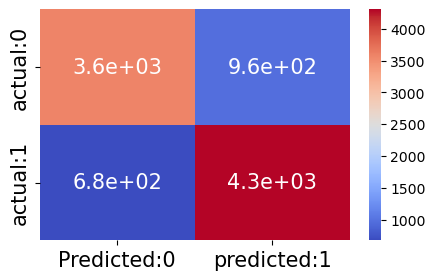

------------------------------------------------------------------------------------
Test_accuracy:0.81
Test classification_report :               precision    recall  f1-score   support

           0       0.83      0.77      0.80     18230
           1       0.80      0.86      0.83     19849

    accuracy                           0.81     38079
   macro avg       0.82      0.81      0.81     38079
weighted avg       0.81      0.81      0.81     38079



In [81]:
train_accuracy = train_acc(log_model)
test_accuracy = test_acc(log_model)
train_cls_report = train_class_report(log_model)
test_cls_report = test_class_report(log_model)
print(f"Train_accuracy:{train_accuracy:.2f}")
print(f"Train classification_report : {train_cls_report}")
conf_matrix(log_model)
print("------------------------------------------------------------------------------------")
print(f"Test_accuracy:{test_accuracy:.2f}")
print(f"Test classification_report : {test_cls_report}")

In [82]:
update_table(log_model,"Train",train_accuracy)
update_table(log_model,"Test",test_accuracy)

In [83]:
knn_model = KNeighborsClassifier()

Train_accuracy:0.97
Train classification_report :               precision    recall  f1-score   support

           0       0.97      0.96      0.97      4538
           1       0.96      0.98      0.97      4982

    accuracy                           0.97      9520
   macro avg       0.97      0.97      0.97      9520
weighted avg       0.97      0.97      0.97      9520



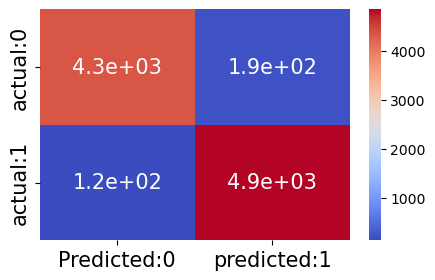

------------------------------------------------------------------------------------
Test_accuracy:0.91
Test classification_report :               precision    recall  f1-score   support

           0       0.91      0.89      0.90     18230
           1       0.90      0.92      0.91     19849

    accuracy                           0.91     38079
   macro avg       0.91      0.90      0.91     38079
weighted avg       0.91      0.91      0.91     38079



In [84]:
train_accuracy = train_acc(knn_model)
test_accuracy = test_acc(knn_model)
train_cls_report = train_class_report(knn_model)
test_cls_report = test_class_report(knn_model)
print(f"Train_accuracy:{train_accuracy:.2f}")
print(f"Train classification_report : {train_cls_report}")
conf_matrix(knn_model)
print("------------------------------------------------------------------------------------")
print(f"Test_accuracy:{test_accuracy:.2f}")
print(f"Test classification_report : {test_cls_report}")

In [85]:
update_table(knn_model,"Train",train_accuracy)
update_table(knn_model,"Test",test_accuracy)

In [86]:
dc_model = DecisionTreeClassifier()

Train_accuracy:0.94
Train classification_report :               precision    recall  f1-score   support

           0       0.94      0.93      0.93      4538
           1       0.93      0.94      0.94      4982

    accuracy                           0.94      9520
   macro avg       0.94      0.94      0.94      9520
weighted avg       0.94      0.94      0.94      9520



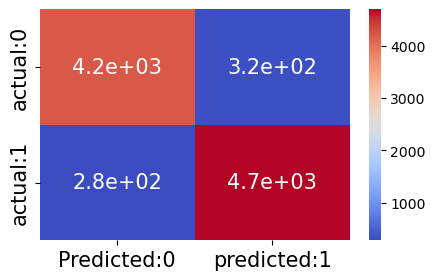

------------------------------------------------------------------------------------
Test_accuracy:0.91
Test classification_report :               precision    recall  f1-score   support

           0       0.91      0.91      0.91     18230
           1       0.92      0.92      0.92     19849

    accuracy                           0.91     38079
   macro avg       0.91      0.91      0.91     38079
weighted avg       0.91      0.91      0.91     38079



In [87]:
train_accuracy = train_acc(dc_model)
test_accuracy = test_acc(dc_model)
train_cls_report = train_class_report(dc_model)
test_cls_report = test_class_report(dc_model)
print(f"Train_accuracy:{train_accuracy:.2f}")
print(f"Train classification_report : {train_cls_report}")
conf_matrix(dc_model)
print("------------------------------------------------------------------------------------")
print(f"Test_accuracy:{test_accuracy:.2f}")
print(f"Test classification_report : {test_cls_report}")

In [88]:
update_table(dc_model,"Train",train_accuracy)
update_table(dc_model,"Test",test_accuracy)

In [89]:
param_grid = {
    "criterion" : ["gini","entropy"],
    "max_depth":[None,1,4,10],
    "min_samples_leaf" : [1,2,3,4,5],
    "min_samples_split" : [2,4,6,8]
}

dc_grid_model = GridSearchCV(estimator=dc_model,
                            param_grid = param_grid,
                            cv=3,
                             scoring="accuracy")
dc_grid_model.fit(x_train,y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 1, 4, 10],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 4, 6, 8]},
             scoring='accuracy')

In [90]:
best_param = dc_grid_model.best_params_
print(best_param)

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [91]:
dc_hyper_model = DecisionTreeClassifier(random_state=42,**best_param)

Train_accuracy:0.93
Train classification_report :               precision    recall  f1-score   support

           0       0.94      0.93      0.93      4538
           1       0.93      0.94      0.94      4982

    accuracy                           0.93      9520
   macro avg       0.93      0.93      0.93      9520
weighted avg       0.93      0.93      0.93      9520



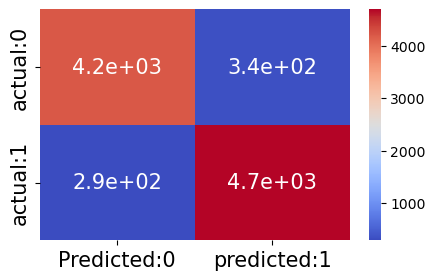

------------------------------------------------------------------------------------
Test_accuracy:0.92
Test classification_report :               precision    recall  f1-score   support

           0       0.92      0.91      0.92     18230
           1       0.92      0.93      0.93     19849

    accuracy                           0.92     38079
   macro avg       0.92      0.92      0.92     38079
weighted avg       0.92      0.92      0.92     38079



In [92]:
train_accuracy = train_acc(dc_hyper_model)
test_accuracy = test_acc(dc_hyper_model)
train_cls_report = train_class_report(dc_hyper_model)
test_cls_report = test_class_report(dc_hyper_model)
print(f"Train_accuracy:{train_accuracy:.2f}")
print(f"Train classification_report : {train_cls_report}")
conf_matrix(dc_hyper_model)
print("------------------------------------------------------------------------------------")
print(f"Test_accuracy:{test_accuracy:.2f}")
print(f"Test classification_report : {test_cls_report}")

In [93]:
update_table(dc_hyper_model,"Train",train_accuracy,"hyper-paramter")
update_table(dc_hyper_model,"Test",test_accuracy,"hyper-parameter")

In [94]:
rf_model = RandomForestClassifier(random_state=42)

Train_accuracy:0.96
Train classification_report :               precision    recall  f1-score   support

           0       0.97      0.94      0.96      4538
           1       0.95      0.97      0.96      4982

    accuracy                           0.96      9520
   macro avg       0.96      0.96      0.96      9520
weighted avg       0.96      0.96      0.96      9520



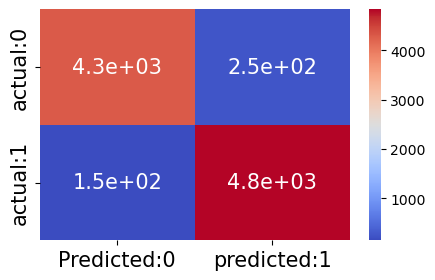

------------------------------------------------------------------------------------
Test_accuracy:0.94
Test classification_report :               precision    recall  f1-score   support

           0       0.95      0.93      0.94     18230
           1       0.94      0.96      0.95     19849

    accuracy                           0.94     38079
   macro avg       0.94      0.94      0.94     38079
weighted avg       0.94      0.94      0.94     38079



In [117]:
train_accuracy = train_acc(rf_model)
test_accuracy = test_acc(rf_model)
train_cls_report = train_class_report(rf_model)
test_cls_report = test_class_report(rf_model)
print(f"Train_accuracy:{train_accuracy:.2f}")
print(f"Train classification_report : {train_cls_report}")
conf_matrix(rf_model)
print("------------------------------------------------------------------------------------")
print(f"Test_accuracy:{test_accuracy:.2f}")
print(f"Test classification_report : {test_cls_report}")

In [118]:
update_table(rf_model,"Train",train_accuracy)
update_table(rf_model,"Test",test_accuracy)

In [119]:
gb_model = GradientBoostingClassifier()

Train_accuracy:0.94
Train classification_report :               precision    recall  f1-score   support

           0       0.95      0.92      0.94      4538
           1       0.93      0.95      0.94      4982

    accuracy                           0.94      9520
   macro avg       0.94      0.94      0.94      9520
weighted avg       0.94      0.94      0.94      9520



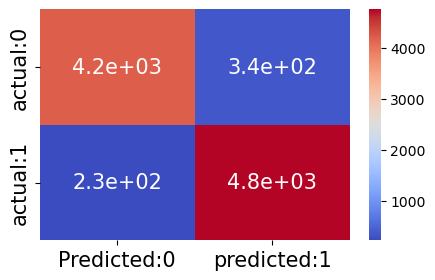

------------------------------------------------------------------------------------
Test_accuracy:0.94
Test classification_report :               precision    recall  f1-score   support

           0       0.95      0.93      0.94     18230
           1       0.93      0.95      0.94     19849

    accuracy                           0.94     38079
   macro avg       0.94      0.94      0.94     38079
weighted avg       0.94      0.94      0.94     38079



In [120]:
train_accuracy = train_acc(gb_model)
test_accuracy = test_acc(gb_model)
train_cls_report = train_class_report(gb_model)
test_cls_report = test_class_report(gb_model)
print(f"Train_accuracy:{train_accuracy:.2f}")
print(f"Train classification_report : {train_cls_report}")
conf_matrix(gb_model)
print("------------------------------------------------------------------------------------")
print(f"Test_accuracy:{test_accuracy:.2f}")
print(f"Test classification_report : {test_cls_report}")

In [128]:
update_table(gb_model,"Train",train_accuracy)
update_table(gb_model,"Test",test_accuracy)

In [122]:
xg_model = XGBClassifier()

Train_accuracy:0.97
Train classification_report :               precision    recall  f1-score   support

           0       0.97      0.97      0.97      4538
           1       0.97      0.97      0.97      4982

    accuracy                           0.97      9520
   macro avg       0.97      0.97      0.97      9520
weighted avg       0.97      0.97      0.97      9520



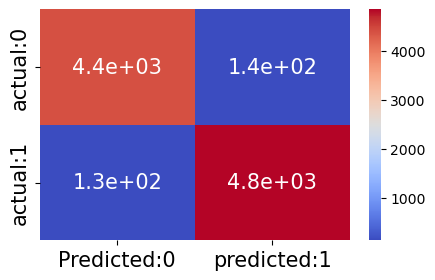

------------------------------------------------------------------------------------
Test_accuracy:0.96
Test classification_report :               precision    recall  f1-score   support

           0       0.96      0.96      0.96     18230
           1       0.96      0.97      0.96     19849

    accuracy                           0.96     38079
   macro avg       0.96      0.96      0.96     38079
weighted avg       0.96      0.96      0.96     38079



In [123]:
train_accuracy = train_acc(xg_model)
test_accuracy = test_acc(xg_model)
train_cls_report = train_class_report(xg_model)
test_cls_report = test_class_report(xg_model)
print(f"Train_accuracy:{train_accuracy:.2f}")
print(f"Train classification_report : {train_cls_report}")
conf_matrix(xg_model)
print("------------------------------------------------------------------------------------")
print(f"Test_accuracy:{test_accuracy:.2f}")
print(f"Test classification_report : {test_cls_report}")

In [129]:
update_table("XG_Boost","Train",train_accuracy)
update_table("XG_Boost","Test",test_accuracy)

In [125]:
# svm = SVC()

In [126]:
# train_accuracy = train_acc(svm)
# test_accuracy = test_acc(svm)
# train_cls_report = train_class_report(svm)
# test_cls_report = test_class_report(svm)
# print(f"Train_accuracy:{train_accuracy:.2f}")
# print(f"Train classification_report : {train_cls_report}")
# conf_matrix(svm)
# print("------------------------------------------------------------------------------------")
# print(f"Test_accuracy:{test_accuracy:.2f}")
# print(f"Test classification_report : {test_cls_report}")

In [127]:
# update_table(svm,"Train",train_accuracy)
# update_table(svm,"Test",test_accuracy)

In [133]:
table

,Model,feature,Train/Test,Accuracy
0,LogisticRegression(),-,Train,0.83
1,LogisticRegression(),-,Test,0.81
2,KNeighborsClassifier(),-,Train,0.97
3,KNeighborsClassifier(),-,Test,0.91
4,DecisionTreeClassifier(),-,Train,0.94
5,DecisionTreeClassifier(),-,Test,0.91
6,"DecisionTreeClassifier(criterion='entropy', ra...",hyper-paramter,Train,0.93
7,"DecisionTreeClassifier(criterion='entropy', ra...",hyper-parameter,Test,0.92
8,RandomForestClassifier(random_state=42),random_forest,Train,0.96
9,RandomForestClassifier(random_state=42),random_forest,Test,0.94


In [134]:
train = table[table["Train/Test"]=="Train"]
test = table[table["Train/Test"]=="Test"]

In [135]:
train

,Model,feature,Train/Test,Accuracy
0,LogisticRegression(),-,Train,0.83
2,KNeighborsClassifier(),-,Train,0.97
4,DecisionTreeClassifier(),-,Train,0.94
6,"DecisionTreeClassifier(criterion='entropy', ra...",hyper-paramter,Train,0.93
8,RandomForestClassifier(random_state=42),random_forest,Train,0.96
10,RandomForestClassifier(random_state=42),-,Train,0.96
12,GradientBoostingClassifier(),-,Train,0.94
14,XG_Boost,-,Train,0.97


Train Accuracy for All Model


[Text(0, 0, '0.97'),
 Text(0, 0, '0.97'),
 Text(0, 0, '0.96'),
 Text(0, 0, '0.94'),
 Text(0, 0, '0.94'),
 Text(0, 0, '0.93'),
 Text(0, 0, '0.83')]

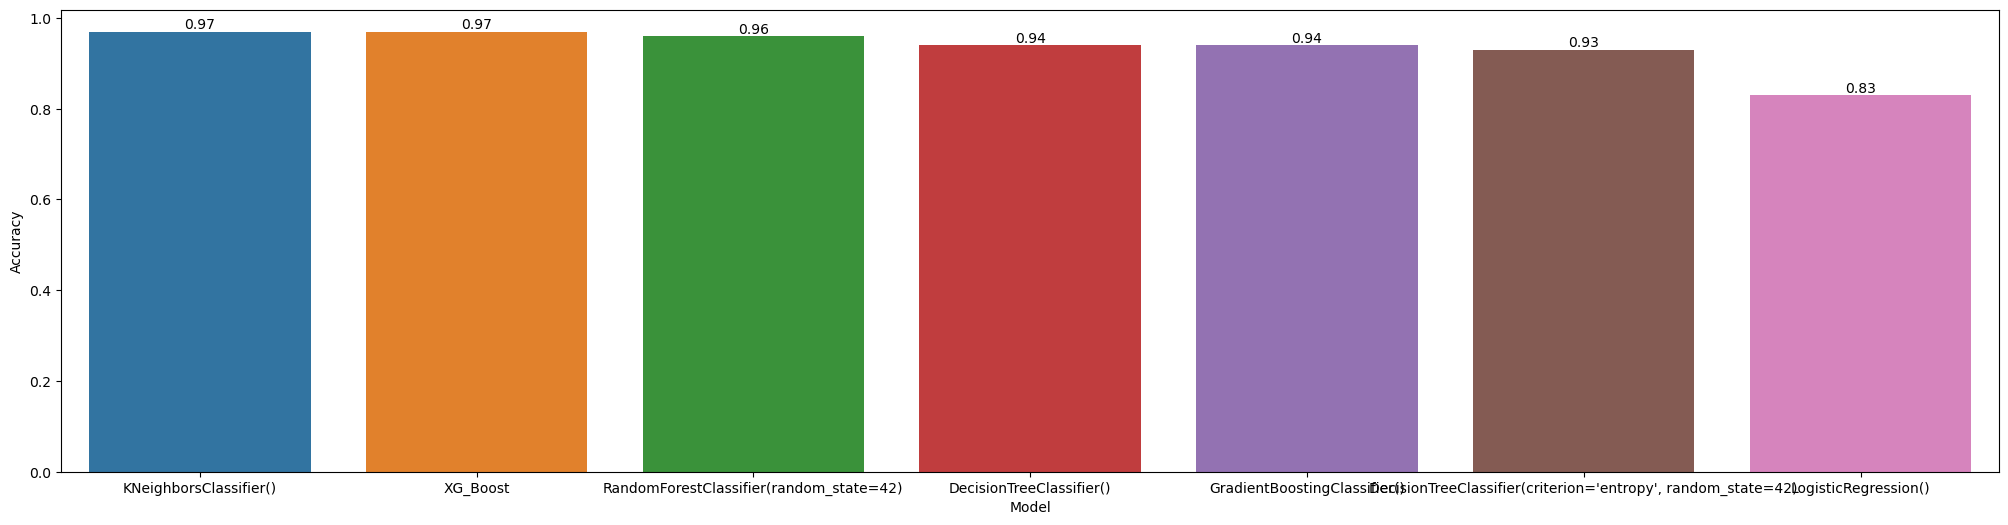

In [140]:
plt.figure(figsize=(25,6))
print("Train Accuracy for All Model") 
df = pd.DataFrame(train,columns=["Model","Accuracy"])
df["Model"] = df["Model"].astype("object")
ax = sns.barplot(df.sort_values(by="Accuracy",ascending=False),x="Model",y="Accuracy")
ax.bar_label(ax.containers[0])
# df.info()

Test Accuracy for All Model


[Text(0, 0, '0.96'),
 Text(0, 0, '0.94'),
 Text(0, 0, '0.94'),
 Text(0, 0, '0.92'),
 Text(0, 0, '0.91'),
 Text(0, 0, '0.91'),
 Text(0, 0, '0.81')]

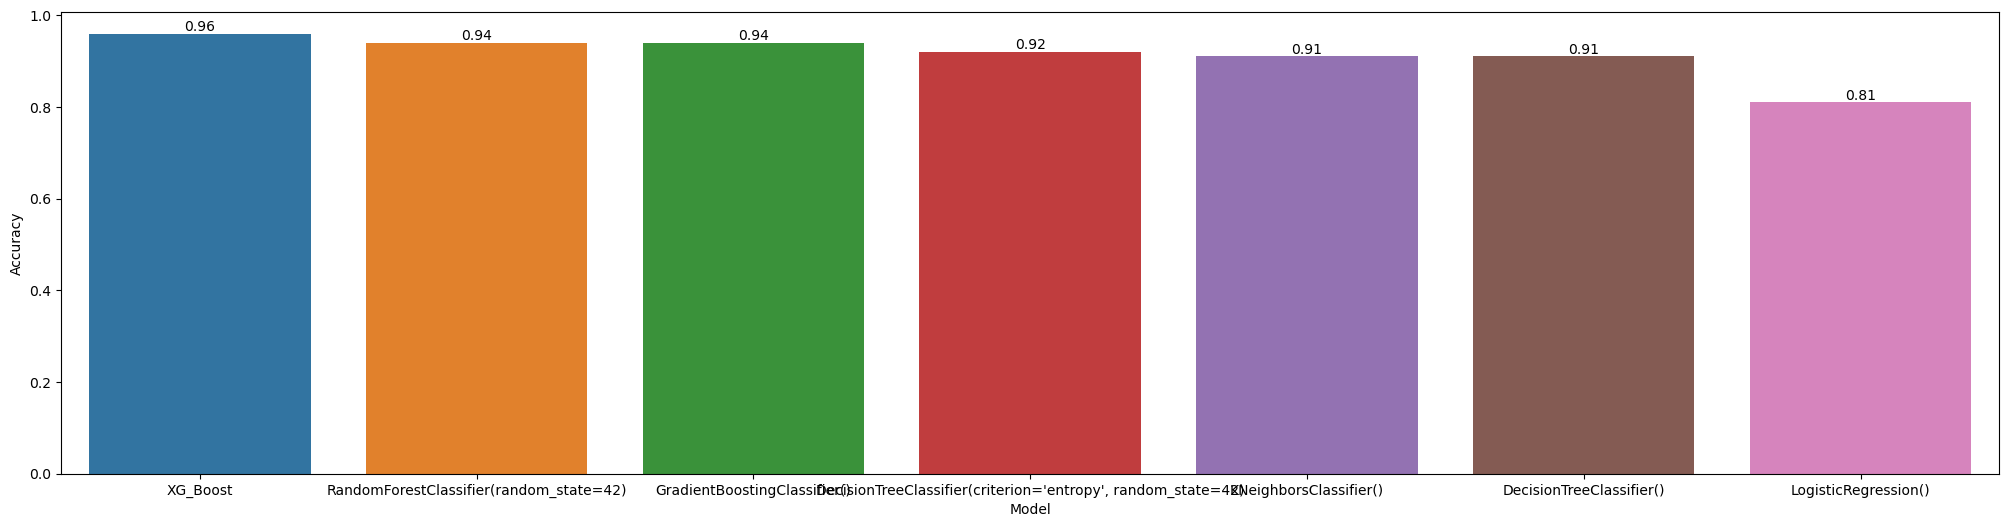

In [141]:
plt.figure(figsize=(25,6))
print("Test Accuracy for All Model")
df = pd.DataFrame(test,columns=["Model","Accuracy"])
ax = sns.barplot(df.sort_values(by="Accuracy",ascending=False),x="Model",y="Accuracy")
ax.bar_label(ax.containers[0])